# ENM 5310 — Aurora precipitation fine-tuning (Head-only, publishable baseline)

Goal: train a small precipitation head on top of **frozen AuroraSmallPretrained**.

This notebook is meant to be the **"results" notebook** (training + eval + plots + saved checkpoints).


## 0) Config (edit only this cell)

In [1]:
from pathlib import Path
from datetime import datetime, timedelta

# Where your existing NetCDFs live (same folder you used)
DATA_DIR = Path("./downloads/era5")

def date_range(start: str, end: str):
    """Inclusive date range as YYYY-MM-DD strings."""
    s = datetime.fromisoformat(start)
    e = datetime.fromisoformat(end)
    out = []
    cur = s
    while cur <= e:
        out.append(cur.strftime("%Y-%m-%d"))
        cur += timedelta(days=1)
    return out

# Deadline-safe split
TRAIN_DATES = date_range("2023-01-01", "2023-01-20")
VAL_DATES   = date_range("2023-01-21", "2023-01-25")

# Training
EPOCHS = 3
LR = 1e-3
BATCH_SIZE = 1   # keep 1 for now (global 720x1440)

# GPU strategy
# If this OOMs, set BACKBONE_ON_GPU=False and we'll run Aurora on CPU and head on GPU.
BACKBONE_ON_GPU = False
HEAD_ON_GPU = True

# Output
OUT_DIR = Path("./runs/aurora_tp_head")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = OUT_DIR / "precip_head.pt"

print("Config loaded.")
print("TRAIN_DATES:", len(TRAIN_DATES))
print("VAL_DATES:", len(VAL_DATES))


# Run mode
DO_TRAIN = True  # True = train (or resume). False = just load checkpoint & plot/infer
RESUME_IF_EXISTS = True  # if True and checkpoint exists, load head weights before training



Config loaded.
TRAIN_DATES: 20
VAL_DATES: 5


In [2]:
################################
## Downloading data if needed ##
################################

from pathlib import Path
import cdsapi

c = cdsapi.Client()
out = Path("downloads/era5")
out.mkdir(parents=True, exist_ok=True)

def download_day(date_str):
    y, m, d = date_str.split("-")

    surf = out / f"{date_str}-surface-level.nc"
    atm  = out / f"{date_str}-atmospheric.nc"
    tp   = out / f"{date_str}-tp-hourly-01_to_06.nc"

    if not surf.exists():
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": [
                    "2m_temperature",
                    "10m_u_component_of_wind",
                    "10m_v_component_of_wind",
                    "mean_sea_level_pressure",
                ],
                "year": y, "month": m, "day": d,
                "time": ["00:00", "06:00", "12:00", "18:00"],
                "format": "netcdf",
            },
            str(surf),
        )

    if not atm.exists():
        c.retrieve(
            "reanalysis-era5-pressure-levels",
            {
                "product_type": "reanalysis",
                "variable": [
                    "temperature",
                    "u_component_of_wind",
                    "v_component_of_wind",
                    "specific_humidity",
                    "geopotential",
                ],
                "pressure_level": ["1000","850","500","200"],
                "year": y, "month": m, "day": d,
                "time": ["00:00", "06:00", "12:00", "18:00"],
                "format": "netcdf",
            },
            str(atm),
        )

    if not tp.exists():
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": ["total_precipitation"],
                "year": y, "month": m, "day": d,
                "time": [f"{h:02d}:00" for h in range(1, 7)],
                "format": "netcdf",
            },
            str(tp),
        )

    print("✓", date_str)


for d in TRAIN_DATES + VAL_DATES:
    download_day(d)


2025-12-18 14:35:43,521 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.


✓ 2023-01-01
✓ 2023-01-02
✓ 2023-01-03
✓ 2023-01-04
✓ 2023-01-05
✓ 2023-01-06
✓ 2023-01-07
✓ 2023-01-08
✓ 2023-01-09
✓ 2023-01-10
✓ 2023-01-11
✓ 2023-01-12
✓ 2023-01-13
✓ 2023-01-14
✓ 2023-01-15
✓ 2023-01-16
✓ 2023-01-17
✓ 2023-01-18
✓ 2023-01-19
✓ 2023-01-20
✓ 2023-01-21
✓ 2023-01-22
✓ 2023-01-23
✓ 2023-01-24
✓ 2023-01-25


## 1) Imports + device

In [3]:
import json
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import xarray as xr

from aurora import Batch, Metadata
from aurora import AuroraSmallPretrained

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


torch: 2.7.1+cu128
cuda available: True
device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2) Load normalization stats (from your baseline)

In [4]:
STATS_PATH = Path("./tp_normalization.json")
assert STATS_PATH.exists(), "Missing tp_normalization.json (run baseline notebook Step 5)."

with open(STATS_PATH, "r") as f:
    stats = json.load(f)

MU = float(stats["mean"])
STD = float(stats["std"])
print("Loaded stats:", stats)
print("MU, STD:", MU, STD)


Loaded stats: {'target': 'log1p_tp_6h', 'mean': 0.0005497062811627984, 'std': 0.0019855170976370573, 'units': 'log(1 + meters)'}
MU, STD: 0.0005497062811627984 0.0019855170976370573


## 3) Helper: build Batch + target for one day

In [5]:
def build_paths(date_str: str):
    """Returns (surf_path, atm_path, tp_path, static_path)."""
    surf = DATA_DIR / f"{date_str}-surface-level.nc"
    atm  = DATA_DIR / f"{date_str}-atmospheric.nc"
    tp   = DATA_DIR / f"{date_str}-tp-hourly-01_to_06.nc"
    static = DATA_DIR / "static.nc"
    return surf, atm, tp, static


def build_batch(date_str: str) -> Batch:
    surf_path, atm_path, _, static_path = build_paths(date_str)
    assert surf_path.exists(), f"Missing {surf_path}"
    assert atm_path.exists(), f"Missing {atm_path}"
    assert static_path.exists(), f"Missing {static_path}"

    static_ds = xr.open_dataset(static_path)
    surf_ds   = xr.open_dataset(surf_path)
    atm_ds    = xr.open_dataset(atm_path)

    # 2 time steps (t0, t1)
    b = Batch(
        surf_vars={
            "2t":  torch.from_numpy(surf_ds["t2m"].values[:2][None]),
            "10u": torch.from_numpy(surf_ds["u10"].values[:2][None]),
            "10v": torch.from_numpy(surf_ds["v10"].values[:2][None]),
            "msl": torch.from_numpy(surf_ds["msl"].values[:2][None]),
        },
        static_vars={
            "z":   torch.from_numpy(static_ds["z"].values[0]),
            "slt": torch.from_numpy(static_ds["slt"].values[0]),
            "lsm": torch.from_numpy(static_ds["lsm"].values[0]),
        },
        atmos_vars={
            "t": torch.from_numpy(atm_ds["t"].values[:2][None]),
            "u": torch.from_numpy(atm_ds["u"].values[:2][None]),
            "v": torch.from_numpy(atm_ds["v"].values[:2][None]),
            "q": torch.from_numpy(atm_ds["q"].values[:2][None]),
            "z": torch.from_numpy(atm_ds["z"].values[:2][None]),
        },
        metadata=Metadata(
            lat=torch.from_numpy(surf_ds.latitude.values),
            lon=torch.from_numpy(surf_ds.longitude.values),
            time=(surf_ds.valid_time.values.astype("datetime64[s]").tolist()[1],),
            atmos_levels=tuple(int(l) for l in atm_ds.pressure_level.values),
        ),
    )

    static_ds.close(); surf_ds.close(); atm_ds.close()
    return b


def build_target(date_str: str) -> torch.Tensor:
    """Returns y_norm with shape [1,1,720,1440] on CPU."""
    _, _, tp_path, _ = build_paths(date_str)
    assert tp_path.exists(), f"Missing {tp_path}"

    tp_ds = xr.open_dataset(tp_path)
    tp = tp_ds["tp"]

    # Sum hours 1..6 (baseline)
    tp6h = tp.sum(dim="valid_time")

    y = torch.from_numpy(tp6h.values.astype("float32"))  # [H,W]
    y_log = torch.log1p(y)
    y_log_bchw = y_log[None, None].contiguous()  # [1,1,H,W]

    y_norm = (y_log_bchw - MU) / STD

    # Safety crop to match Aurora's 720 latitude grid
    y_norm = y_norm[:, :, :720, :].contiguous()

    tp_ds.close()
    return y_norm


## 4) Helper: pack Aurora features

In [6]:
def pack_surf_features(pred_batch: Batch) -> torch.Tensor:
    x2t  = pred_batch.surf_vars["2t"]
    x10u = pred_batch.surf_vars["10u"]
    x10v = pred_batch.surf_vars["10v"]
    xmsl = pred_batch.surf_vars["msl"]

    X = torch.cat([x2t, x10u, x10v, xmsl], dim=1).float()  # [B,4,H,W]

    # Per-channel standardization (per sample)
    mean = X.mean(dim=(2,3), keepdim=True)
    std  = X.std(dim=(2,3), keepdim=True).clamp_min(1e-6)
    X = (X - mean) / std

    return X


## 5) Model: Aurora (frozen) + Precip head (trainable)

In [7]:
class PrecipHead(nn.Module):
    def __init__(self, in_ch=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=1),
        )
    def forward(self, x):
        return self.net(x)


model = AuroraSmallPretrained(use_lora=False)
model.load_checkpoint("microsoft/aurora", "aurora-0.25-small-pretrained.ckpt")
model.eval()

for p in model.parameters():
    p.requires_grad_(False)

head = PrecipHead(in_ch=4)

if BACKBONE_ON_GPU and device.type == "cuda":
    model = model.to("cuda")
else:
    model = model.to("cpu")

if HEAD_ON_GPU and device.type == "cuda":
    head = head.to("cuda")
else:
    head = head.to("cpu")

print("Backbone device:", next(model.parameters()).device)
print("Head device:", next(head.parameters()).device)


Backbone device: cpu
Head device: cuda:0


In [8]:
import torch

# storage for curves even if we only load
history = {
    "train_loss": [],
    "val_loss": [],
    "val_corr": [],
    # NEW: dense logging
    "train_step_loss": [],       # list of lists
    "train_step_dates": [],      # list of lists (same shape as above)
    "val_day_loss": [],          # list of lists (per epoch)
    "val_day_corr": [],          # list of lists (per epoch)
    "val_day_dates": [],         # list of lists
}


if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
    head.load_state_dict(ckpt["head_state_dict"])
    head.eval()
    if "history" in ckpt:
        history = ckpt["history"]
    print(f"✓ Loaded checkpoint: {CHECKPOINT_PATH}")
    print("  last train_loss:", history["train_loss"][-1] if len(history["train_loss"]) else None)
    print("  last val_loss:",   history["val_loss"][-1]   if len(history["val_loss"]) else None)
    print("  last val_corr:",   history["val_corr"][-1]   if len(history["val_corr"]) else None)
else:
    print("No checkpoint found yet at:", CHECKPOINT_PATH)


✓ Loaded checkpoint: runs\aurora_tp_head\precip_head.pt
  last train_loss: 0.15239178463816644
  last val_loss: 0.16536712646484375
  last val_corr: 0.21037135720252992


## 6) Minimal training/eval loops (head-only)

Important rules (so we don't blow VRAM):
- Aurora forward runs under `torch.no_grad()` (backbone is frozen).
- We delete `pred` and `batch_*` every iteration.
- We only keep the head gradients.

Also: `torch.inference_mode()` creates *inference tensors* that can break autograd if you feed them into a trainable head.
So we use `no_grad()` here.


In [9]:
# Loss: make storms matter more than pure MSE-on-normalized (deadline-safe)
loss_fn = nn.SmoothL1Loss(beta=1.0)
opt = optim.Adam(head.parameters(), lr=LR)

def move_batch(b: Batch, dev: torch.device) -> Batch:
    return b.to(str(dev))


def corrcoef_map(a: torch.Tensor, b: torch.Tensor) -> float:
    """Pearson correlation between two [1,1,H,W] tensors."""
    a = a.detach().float().view(-1)
    b = b.detach().float().view(-1)
    a = a - a.mean()
    b = b - b.mean()
    denom = (a.std(unbiased=False) * b.std(unbiased=False)).clamp_min(1e-12)
    return float((a * b).mean() / denom)


@torch.no_grad()
def eval_one(date_str: str):
    model.eval(); head.eval()

    b = build_batch(date_str)
    y = build_target(date_str)  # CPU

    bb_dev = next(model.parameters()).device
    b_dev = move_batch(b, bb_dev)

    pred = model(b_dev)
    X = pack_surf_features(pred)

    h_dev = next(head.parameters()).device
    X = X.to(h_dev)
    y = y.to(h_dev)

    yhat = head(X)
    loss = float(loss_fn(yhat, y).item())

    # correlation (compute on CPU for stability)
    corr = corrcoef_map(yhat.to("cpu"), y.to("cpu"))

    del b, b_dev, pred, X, y, yhat
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return loss, corr


def train_one_epoch(dates):
    model.eval()      # always frozen
    head.train()

    step_losses = []   # loss per training sample (date)
    dates_seen = []

    for i, date_str in enumerate(dates):
        b = build_batch(date_str)
        y = build_target(date_str)  # CPU

        bb_dev = next(model.parameters()).device
        b_dev = move_batch(b, bb_dev)

        # Aurora forward (no grad)
        with torch.no_grad():
            pred = model(b_dev)
            X = pack_surf_features(pred)

        # IMPORTANT: clone so we can backprop through head safely
        X = X.clone()

        # Move X + y to head device
        h_dev = next(head.parameters()).device
        X = X.to(h_dev)
        y = y.to(h_dev)

        # Head training
        opt.zero_grad(set_to_none=True)
        yhat = head(X)
        loss = loss_fn(yhat, y)
        loss.backward()
        opt.step()

        step_losses.append(float(loss.item()))
        dates_seen.append(date_str)

        # cleanup aggressively
        del b, b_dev, pred, X, y, yhat, loss
        if device.type == "cuda":
            torch.cuda.empty_cache()

        if (i % 1) == 0:
            print(f"  train sample {i+1}/{len(dates)} | loss {step_losses[-1]:.6f} | date {date_str}")

    # return both the mean and the per-step series
    return float(np.mean(step_losses)) if len(step_losses) else float("nan"), dates_seen, step_losses


## 7) Run training + validation

Adds proper evaluation:
- Val loss
- Val correlation (Pearson corr between predicted/target maps)


In [10]:
print("DO_TRAIN:", DO_TRAIN)
print("Checkpoint exists:", CHECKPOINT_PATH.exists())
print("TRAIN_DATES:", len(TRAIN_DATES), "| VAL_DATES:", len(VAL_DATES))

if DO_TRAIN:
    # If user wants fresh training regardless of checkpoint:
    if CHECKPOINT_PATH.exists() and (not RESUME_IF_EXISTS):
        print("Checkpoint exists but RESUME_IF_EXISTS=False => training from scratch head weights")
        head.apply(lambda m: m.reset_parameters() if hasattr(m, "reset_parameters") else None)

    # If we loaded checkpoint earlier, training continues from it automatically
    for ep in range(EPOCHS):
        print(f"\n=== Epoch {ep+1}/{EPOCHS} ===")
        train_loss, step_dates, step_losses = train_one_epoch(TRAIN_DATES)
        history["train_loss"].append(train_loss)
        history.setdefault("train_step_loss", []).append(step_losses)
        history.setdefault("train_step_dates", []).append(step_dates)


        if len(VAL_DATES) > 0:
            vals = [eval_one(d) for d in VAL_DATES]  # list of (loss, corr)
            day_losses = [float(v[0]) for v in vals]
            day_corrs  = [float(v[1]) for v in vals]
            val_loss = float(np.mean(day_losses))
            val_corr = float(np.mean(day_corrs))

            history.setdefault("val_day_loss", []).append(day_losses)
            history.setdefault("val_day_corr", []).append(day_corrs)
            history.setdefault("val_day_dates", []).append(list(VAL_DATES))
        else:
            val_loss = float("nan")
            val_corr = float("nan") 


        history["val_loss"].append(val_loss)
        history["val_corr"].append(val_corr)

        print(f"Epoch {ep+1}: train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | val_corr={val_corr:.4f}")

        torch.save(
            {
                "head_state_dict": head.state_dict(),
                "config": {
                    "TRAIN_DATES": TRAIN_DATES,
                    "VAL_DATES": VAL_DATES,
                    "LR": LR,
                    "EPOCHS": EPOCHS,
                    "BACKBONE_ON_GPU": BACKBONE_ON_GPU,
                    "HEAD_ON_GPU": HEAD_ON_GPU,
                    "MU": MU,
                    "STD": STD,
                    "LOSS": "SmoothL1Loss(beta=1.0)",
                },
                "history": history,
            },
            CHECKPOINT_PATH,
        )
        print("Saved:", CHECKPOINT_PATH)

else:
    if not CHECKPOINT_PATH.exists():
        print("DO_TRAIN=False but no checkpoint found. Set DO_TRAIN=True once to train.")
    else:
        print("Skipping training; using loaded checkpoint.")


DO_TRAIN: True
Checkpoint exists: True
TRAIN_DATES: 20 | VAL_DATES: 5

=== Epoch 1/3 ===
  train sample 1/20 | loss 0.148395 | date 2023-01-01
  train sample 2/20 | loss 0.150172 | date 2023-01-02
  train sample 3/20 | loss 0.161206 | date 2023-01-03
  train sample 4/20 | loss 0.169748 | date 2023-01-04
  train sample 5/20 | loss 0.175613 | date 2023-01-05
  train sample 6/20 | loss 0.161526 | date 2023-01-06
  train sample 7/20 | loss 0.150484 | date 2023-01-07
  train sample 8/20 | loss 0.135150 | date 2023-01-08
  train sample 9/20 | loss 0.142050 | date 2023-01-09
  train sample 10/20 | loss 0.155439 | date 2023-01-10
  train sample 11/20 | loss 0.154166 | date 2023-01-11
  train sample 12/20 | loss 0.143443 | date 2023-01-12
  train sample 13/20 | loss 0.151370 | date 2023-01-13
  train sample 14/20 | loss 0.148165 | date 2023-01-14
  train sample 15/20 | loss 0.148768 | date 2023-01-15
  train sample 16/20 | loss 0.139225 | date 2023-01-16
  train sample 17/20 | loss 0.143997 | d

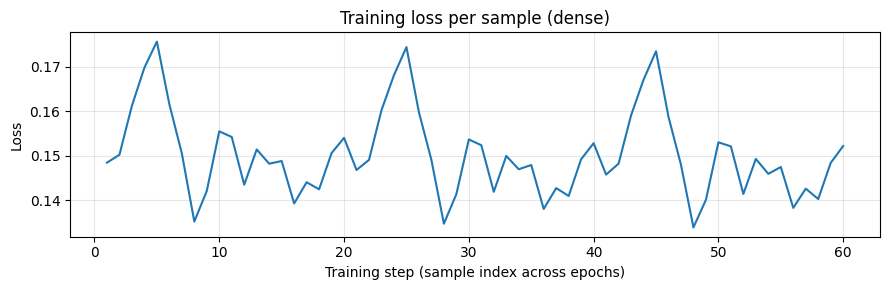

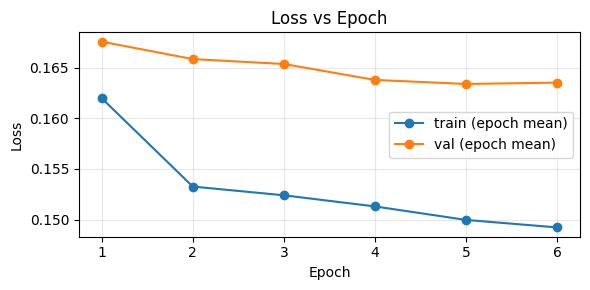

In [11]:
import numpy as np
import matplotlib.pyplot as plt

if "train_step_loss" in history and len(history["train_step_loss"]) > 0:
    y = np.concatenate([np.array(x, dtype=float) for x in history["train_step_loss"]])
    x = np.arange(1, len(y) + 1)

    plt.figure(figsize=(9, 3))
    plt.plot(x, y)
    plt.title("Training loss per sample (dense)")
    plt.xlabel("Training step (sample index across epochs)")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No train_step_loss recorded yet.")


# more plots
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6, 3))
plt.plot(epochs, history["train_loss"], marker="o", label="train (epoch mean)")
if len(history.get("val_loss", [])) == len(history["train_loss"]):
    plt.plot(epochs, history["val_loss"], marker="o", label="val (epoch mean)")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 8) Quick qualitative plot (one day)
This is what you can screenshot for your report: target vs prediction.

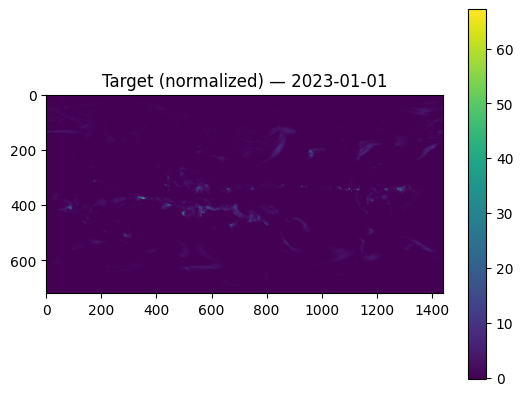

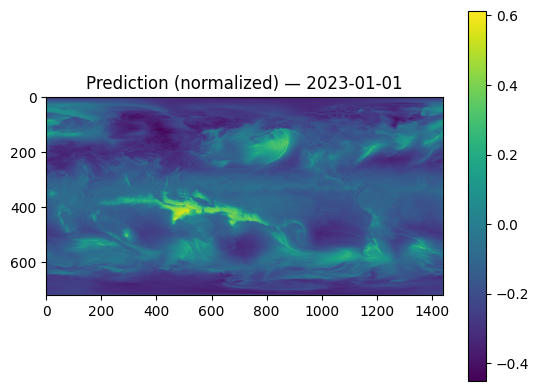

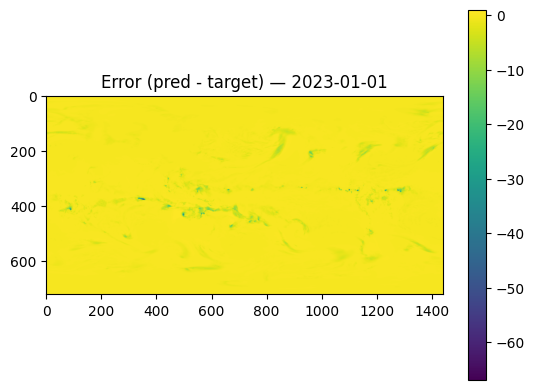

In [12]:
import matplotlib.pyplot as plt

def predict_map(date_str: str):
    model.eval(); head.eval()
    b = build_batch(date_str)
    y = build_target(date_str)  # CPU

    bb_dev = next(model.parameters()).device
    h_dev  = next(head.parameters()).device
    b_dev = move_batch(b, bb_dev)

    with torch.no_grad():
        pred = model(b_dev)
        X = pack_surf_features(pred).to(h_dev)
        yhat = head(X)

    yhat_cpu = yhat.detach().to("cpu").squeeze().numpy()
    y_cpu    = y.detach().to("cpu").squeeze().numpy()

    del b, b_dev, pred, X, yhat, y
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return y_cpu, yhat_cpu


SHOW_DATE = TRAIN_DATES[0]
y_true, y_pred = predict_map(SHOW_DATE)

plt.figure()
plt.title(f"Target (normalized) — {SHOW_DATE}")
plt.imshow(y_true)
plt.colorbar()
plt.show()

plt.figure()
plt.title(f"Prediction (normalized) — {SHOW_DATE}")
plt.imshow(y_pred)
plt.colorbar()
plt.show()

plt.figure()
plt.title(f"Error (pred - target) — {SHOW_DATE}")
plt.imshow(y_pred - y_true)
plt.colorbar()
plt.show()


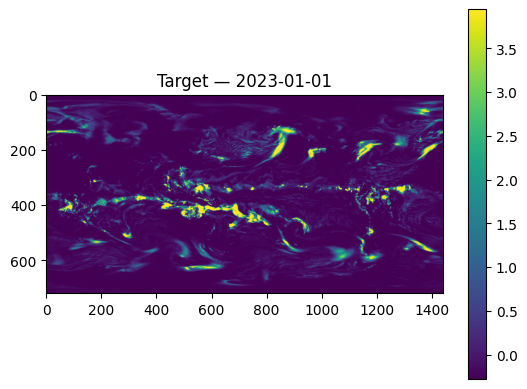

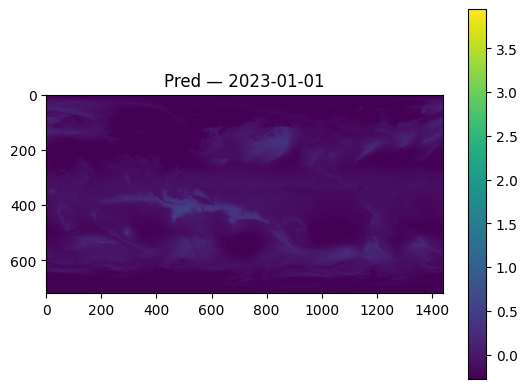

In [13]:
vmin = np.percentile(y_true, 1)
vmax = np.percentile(y_true, 99)

plt.figure(); plt.title(f"Target — {SHOW_DATE}"); plt.imshow(y_true, vmin=vmin, vmax=vmax); plt.colorbar(); plt.show()
plt.figure(); plt.title(f"Pred — {SHOW_DATE}");   plt.imshow(y_pred, vmin=vmin, vmax=vmax); plt.colorbar(); plt.show()


## 9) If GPU OOM happens
Only change in config:
- set `BACKBONE_ON_GPU = False`
- keep `HEAD_ON_GPU = True`

That runs Aurora on CPU and the head on GPU (still much faster than full CPU training).


In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm

def denorm_to_mm(y_norm: torch.Tensor, mu=MU, std=STD) -> torch.Tensor:
    """
    y_norm: [1,1,H,W] normalized target/pred
    returns precip in mm (nonnegative): [H,W] torch tensor on CPU
    """
    y_log = y_norm * std + mu                    # log1p(meters)
    y_m   = torch.expm1(y_log).clamp_min(0.0)    # meters
    y_mm  = y_m * 1000.0                         # mm
    return y_mm.squeeze().detach().to("cpu")

@torch.no_grad()
def predict_norm(date_str: str) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Returns (y_true_norm, y_pred_norm, metadata_lat_lon) where:
      y_true_norm: [1,1,H,W] on CPU
      y_pred_norm: [1,1,H,W] on CPU
      lat, lon: 1D torch tensors on CPU
    """
    model.eval(); head.eval()

    b = build_batch(date_str)
    y_true = build_target(date_str)  # CPU [1,1,H,W]

    bb_dev = next(model.parameters()).device
    h_dev  = next(head.parameters()).device

    b_dev = move_batch(b, bb_dev)

    # IMPORTANT: use no_grad (not inference_mode) so output can be fed into a trainable head safely
    with torch.no_grad():
        pred = model(b_dev)
        X = pack_surf_features(pred)

    # FIX: clone() so X is a "normal" tensor and autograd won't complain if you later train
    X = X.clone().to(h_dev)

    y_pred = head(X).detach().to("cpu")

    lat = b.metadata.lat.detach().to("cpu")
    lon = b.metadata.lon.detach().to("cpu")

    # cleanup
    del b, b_dev, pred, X
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return y_true, y_pred, (lat, lon)

def lon_to_0360(lon_val: float) -> float:
    lon_val = float(lon_val)
    return lon_val % 360.0

def crop_latlon(arr_hw: np.ndarray, lat: np.ndarray, lon: np.ndarray,
                lat_min: float, lat_max: float, lon_min: float, lon_max: float):
    """
    arr_hw: [H,W], lat: [H] descending, lon: [W] in [0,360)
    returns cropped array and cropped lat/lon
    """
    # lat indices
    lat_lo, lat_hi = min(lat_min, lat_max), max(lat_min, lat_max)
    lat_mask = (lat >= lat_lo) & (lat <= lat_hi)  # lat descending still fine

    # lon indices (support wrap)
    lo = lon_to_0360(lon_min)
    hi = lon_to_0360(lon_max)
    if lo <= hi:
        lon_mask = (lon >= lo) & (lon <= hi)
        out = arr_hw[np.ix_(lat_mask, lon_mask)]
        return out, lat[lat_mask], lon[lon_mask]
    else:
        # wrap-around: e.g., 350..10
        lon_mask1 = (lon >= lo)
        lon_mask2 = (lon <= hi)
        out1 = arr_hw[np.ix_(lat_mask, lon_mask1)]
        out2 = arr_hw[np.ix_(lat_mask, lon_mask2)]
        out = np.concatenate([out1, out2], axis=1)
        lon_out = np.concatenate([lon[lon_mask1], lon[lon_mask2]])
        return out, lat[lat_mask], lon_out

def pearson_corr(a: np.ndarray, b: np.ndarray) -> float:
    a = a.reshape(-1).astype(np.float64)
    b = b.reshape(-1).astype(np.float64)
    a = a - a.mean()
    b = b - b.mean()
    denom = (a.std() * b.std()) + 1e-12
    return float((a * b).mean() / denom)


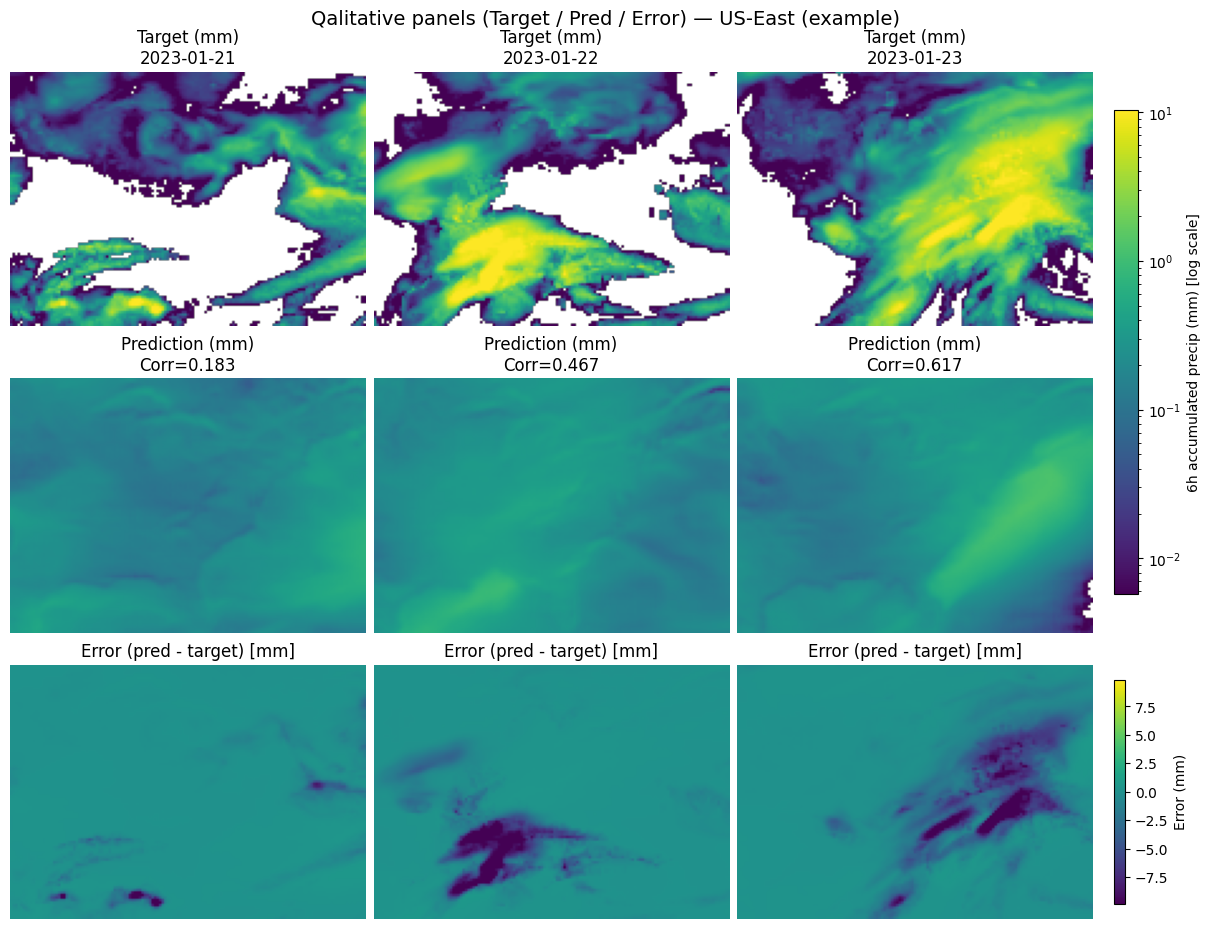

In [15]:
# ---- choose which dates to visualize ----
# pick a few validation cases if you have them; otherwise use a few training
SHOW_DATES = (VAL_DATES[:3] if len(VAL_DATES) else TRAIN_DATES[:3])

# ---- optional: region zoom (set USE_REGION=False to plot global) ----
USE_REGION = True
REGION = {
    "name": "US-East (example)",
    "lat_min": 25, "lat_max": 50,
    "lon_min": 260, "lon_max": 295,   # 0..360 convention (260=100W, 295=65W)
}

# collect fields
cases = []
for d in SHOW_DATES:
    y_true_n, y_pred_n, (lat_t, lon_t) = predict_norm(d)

    y_true_mm = denorm_to_mm(y_true_n).numpy()
    y_pred_mm = denorm_to_mm(y_pred_n).numpy()
    err_mm    = (y_pred_mm - y_true_mm)

    lat = lat_t.numpy()
    lon = lon_t.numpy()

    if USE_REGION:
        y_true_mm, lat_c, lon_c = crop_latlon(y_true_mm, lat, lon, **{k: REGION[k] for k in ["lat_min","lat_max","lon_min","lon_max"]})
        y_pred_mm, _, _ = crop_latlon(y_pred_mm, lat, lon, **{k: REGION[k] for k in ["lat_min","lat_max","lon_min","lon_max"]})
        err_mm,    _, _ = crop_latlon(err_mm,    lat, lon, **{k: REGION[k] for k in ["lat_min","lat_max","lon_min","lon_max"]})
        lat, lon = lat_c, lon_c

    corr = pearson_corr(y_true_mm, y_pred_mm)
    cases.append((d, y_true_mm, y_pred_mm, err_mm, corr, lat, lon))

# shared color limits (log) for precip across all shown cases
all_true = np.concatenate([c[1].reshape(-1) for c in cases])
all_pred = np.concatenate([c[2].reshape(-1) for c in cases])
all_pp   = np.concatenate([all_true, all_pred])

# avoid zeros for LogNorm
eps = 1e-3  # mm
vmin = max(eps, np.percentile(all_pp[all_pp > 0], 5)) if np.any(all_pp > 0) else eps
vmax = np.percentile(all_pp, 99.5) if np.any(all_pp > 0) else 1.0

# error symmetric limits
eabs = np.percentile(np.abs(np.concatenate([c[3].reshape(-1) for c in cases])), 99.0)
eabs = max(eabs, 1e-3)

n = len(cases)
fig, axes = plt.subplots(3, n, figsize=(4*n, 9), constrained_layout=True)

if n == 1:
    axes = np.array(axes).reshape(3, 1)

for j, (d, y_t, y_p, e, corr, lat, lon) in enumerate(cases):
    ax0, ax1, ax2 = axes[0, j], axes[1, j], axes[2, j]

    im0 = ax0.imshow(y_t, norm=LogNorm(vmin=vmin, vmax=vmax))
    ax0.set_title(f"Target (mm)\n{d}")
    ax0.axis("off")

    im1 = ax1.imshow(y_p, norm=LogNorm(vmin=vmin, vmax=vmax))
    ax1.set_title(f"Prediction (mm)\nCorr={corr:.3f}")
    ax1.axis("off")

    im2 = ax2.imshow(e, norm=TwoSlopeNorm(vmin=-eabs, vcenter=0.0, vmax=eabs))
    ax2.set_title("Error (pred - target) [mm]")
    ax2.axis("off")

# colorbars (one for precip, one for error)
cbar0 = fig.colorbar(im0, ax=axes[0, :].tolist() + axes[1, :].tolist(), shrink=0.85, pad=0.02)
cbar0.set_label("6h accumulated precip (mm) [log scale]")

cbar1 = fig.colorbar(im2, ax=axes[2, :].tolist(), shrink=0.85, pad=0.02)
cbar1.set_label("Error (mm)")

title_region = f" — {REGION['name']}" if USE_REGION else ""
fig.suptitle(f"Qalitative panels (Target / Pred / Error){title_region}", y=1.02, fontsize=14)
plt.show()


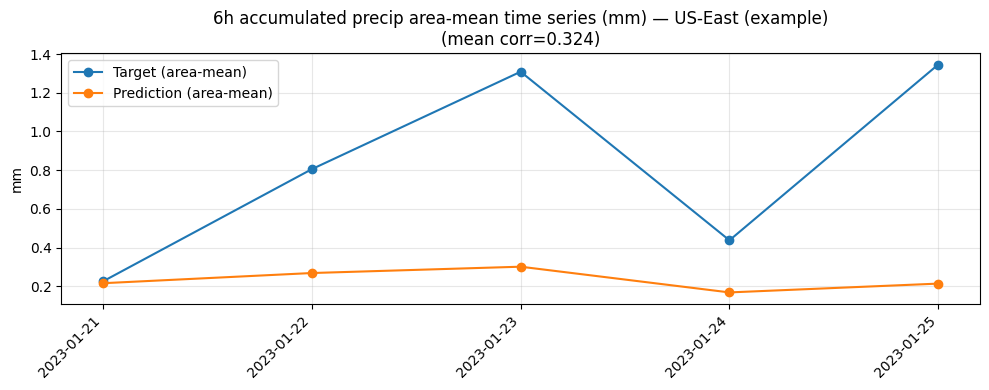

In [16]:
# choose dates for time-series (prefer VAL)
TS_DATES = VAL_DATES if len(VAL_DATES) else TRAIN_DATES

USE_REGION_TS = True
REGION_TS = {
    "name": "US-East (example)",
    "lat_min": 25, "lat_max": 50,
    "lon_min": 260, "lon_max": 295,
}

dates = []
true_mean = []
pred_mean = []
corrs = []

for d in TS_DATES:
    y_true_n, y_pred_n, (lat_t, lon_t) = predict_norm(d)
    y_true_mm = denorm_to_mm(y_true_n).numpy()
    y_pred_mm = denorm_to_mm(y_pred_n).numpy()

    lat = lat_t.numpy()
    lon = lon_t.numpy()

    if USE_REGION_TS:
        y_true_mm, _, _ = crop_latlon(y_true_mm, lat, lon, **{k: REGION_TS[k] for k in ["lat_min","lat_max","lon_min","lon_max"]})
        y_pred_mm, _, _ = crop_latlon(y_pred_mm, lat, lon, **{k: REGION_TS[k] for k in ["lat_min","lat_max","lon_min","lon_max"]})

    dates.append(d)
    true_mean.append(float(np.mean(y_true_mm)))
    pred_mean.append(float(np.mean(y_pred_mm)))
    corrs.append(pearson_corr(y_true_mm, y_pred_mm))

plt.figure(figsize=(10, 4))
plt.plot(dates, true_mean, marker="o", label="Target (area-mean)")
plt.plot(dates, pred_mean, marker="o", label="Prediction (area-mean)")
plt.xticks(rotation=45, ha="right")
name = REGION_TS["name"] if USE_REGION_TS else "Global"
plt.title(f"6h accumulated precip area-mean time series (mm) — {name}\n(mean corr={np.mean(corrs):.3f})")
plt.ylabel("mm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
